In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

Shape: (6016, 4016, 3)
Dtype: uint8


(np.float64(-0.5), np.float64(4015.5), np.float64(6015.5), np.float64(-0.5))

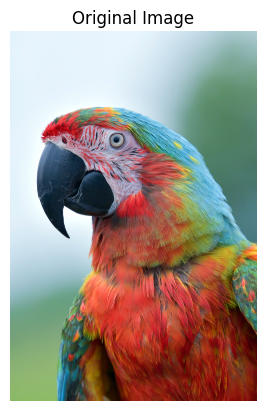

In [90]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open('/content/drive/MyDrive/Semester-6/Week1/bird.jpg')
img_array=np.array(img)
print("Shape:", img_array.shape)
print("Dtype:", img_array.dtype)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

Image.open() loads the file. np.array() converts it to a 3D array of shape (height, width, 3) where the 3 channels are R, G, B. Each pixel value is 0–255.

Task2

 consits of Array slciing where  [row, columns, channels]
  rows 0-99, Columns 0-99, all 3 channels
  

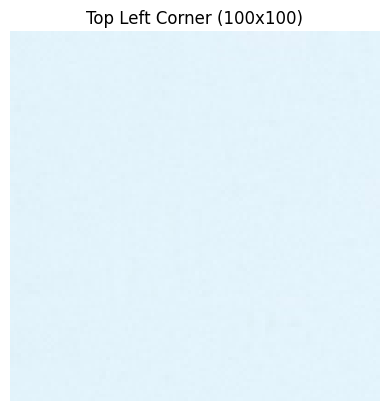

In [91]:
top_left_corner = img_array[0:100,0:100, :]

plt.imshow(top_left_corner)
plt.title("Top Left Corner (100x100)")
plt.axis('off')
plt.show()

Task 3

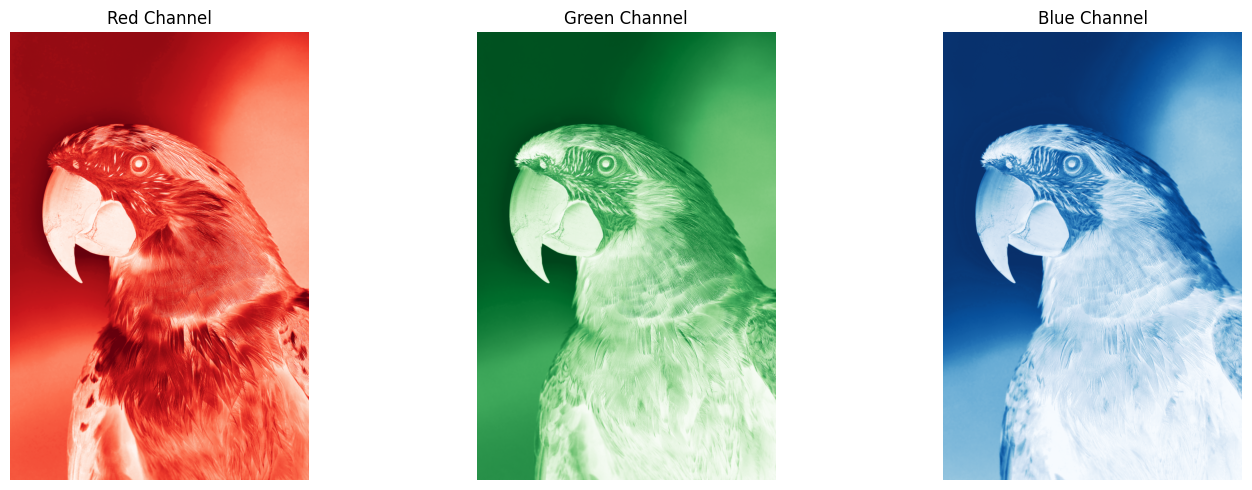

In [92]:
red_channel = img_array[:,:, 0]     #index 0 which is Red
green_channel = img_array[:, :, 1]  #index 1 is Green
blue_channel = img_array[:, :, 2]   # index 2 is Blue

fig, axes = plt.subplots(1,3, figsize=(15, 5))
axes[0].imshow(red_channel, cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(blue_channel, cmap="Blues")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Task4

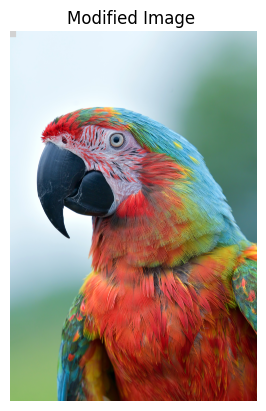

In [93]:
modified = img_array.copy()

# Makign where all the channels of top left has light gray and value set to 210
modified[0:100, 0:100, :] = 210
plt.imshow(modified)
plt.title("Modified Image ")
plt.axis("off")
plt.show()

Exercise 2

Task1

Shape: (408, 612)
Dtype: uint8


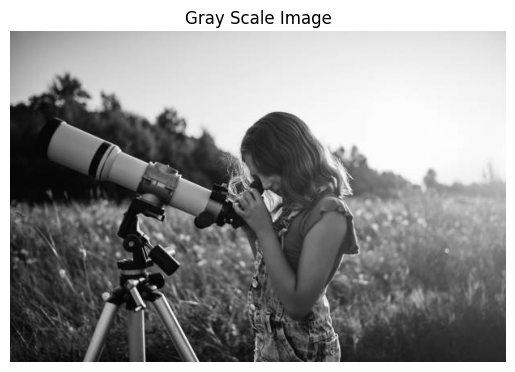

In [33]:
img = Image.open('/content/drive/MyDrive/Semester-6/Week1/telescope.jpg')
# Loading image as  grayscale in pillow its mode L
img_gray = img.convert('L')
img_array=np.array(img_gray)

print("Shape:", img_array.shape)
print("Dtype:", img_array.dtype)

plt.imshow(img_array, cmap="gray")
plt.title("Gray Scale Image")
plt.axis('off')
plt.show()

Task2

Middle  section (150, 150)


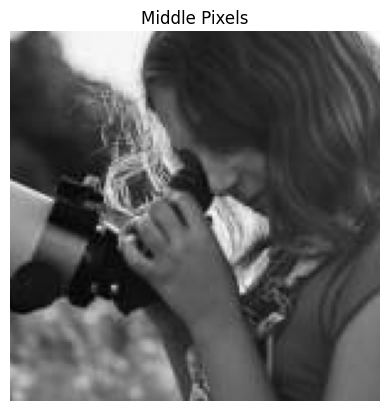

In [28]:
height, width = img_array.shape

center_row = height // 2
center_col = width // 2

# slicing 75 pixel in  each direction from the center total 150*150 total
middle = img_array[center_row - 75 : center_row + 75,
                   center_col - 75 : center_col +  75]

print("Middle  section", middle.shape)
plt.imshow(middle, cmap='gray')
plt.title("Middle Pixels")
plt.axis("off")
plt.show()

Task3

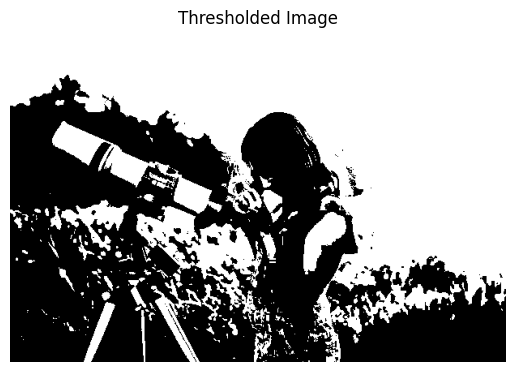

In [30]:
thresholded = img_array.copy()

thresholded[thresholded < 100] = 0
thresholded[thresholded >= 100] = 255

plt.imshow(thresholded, cmap = 'gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

Task4

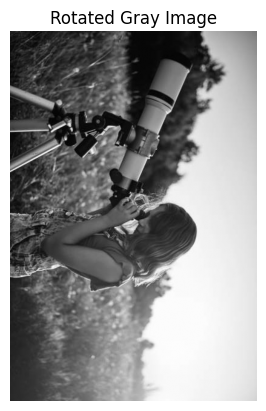

In [37]:
img_rotated = img.rotate(-90, expand=True)
img_gray = img_rotated.convert('L')
# Display
plt.imshow(img_gray, cmap='gray')
plt.title("Rotated Gray Image")
plt.axis("off")
plt.show()

Task5

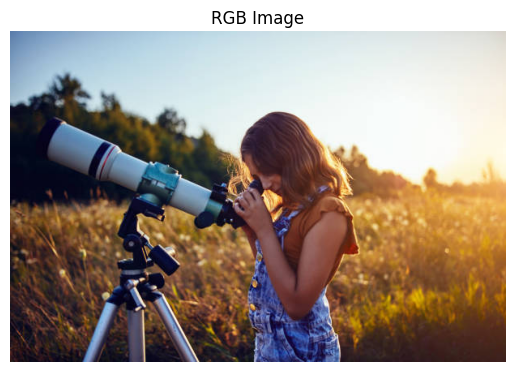

In [39]:
Img_rib = img.convert('RGB')
plt.imshow(Img_rib)
plt.title("RGB Image")
plt.axis('off')
plt.show()

Question3

Task1

In [80]:
img = Image.open("/content/drive/MyDrive/Semester-6/Week1/bird.jpg")

img_gray = img.convert("L")

img_array = np.array(img_gray, dtype=np.float64)
print("Grayscale image shape:", img_array.shape)



Grayscale image shape: (6016, 4016)


In [81]:
mean= np.mean(img_array, axis=0)
centered = img_array - mean

print("Mean shape: ", mean.shape)
print("Centered shape:", centered.shape)
print("Mean of centered (should be ~0):", np.abs(centered.mean()).round(10))

Mean shape:  (4016,)
Centered shape: (6016, 4016)
Mean of centered (should be ~0): 0.0


In [82]:
n=centered.shape[0]
cov_matrix = (centered.T @ centered) / (n - 1)

print("Covariance matrix shape:",cov_matrix.shape)

Covariance matrix shape: (4016, 4016)


In [83]:
#Step2 - Eigen decomposition
# Compute eigenvalues and eigenvectors from scratch using numpy's linalg
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh is used for symmetric matrices (covariance is always symmetric)

# eigh returns in ASCENDING order — reverse to get descending
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Eigenvalues shape:", eigenvalues.shape)    # (W,)
print("Eigenvectors shape:", eigenvectors.shape)  # (W, W)
print("Top 5 eigenvalues:", eigenvalues[:5].round(2))

Eigenvalues shape: (4016,)
Eigenvectors shape: (4016, 4016)
Top 5 eigenvalues: [8634721.38 2116870.5  1106370.98  291636.75  260815.41]


80% variance explained by 4 components
90% variance explained by 20 components
95% variance explained by 129 components
99% variance explained by 479 components


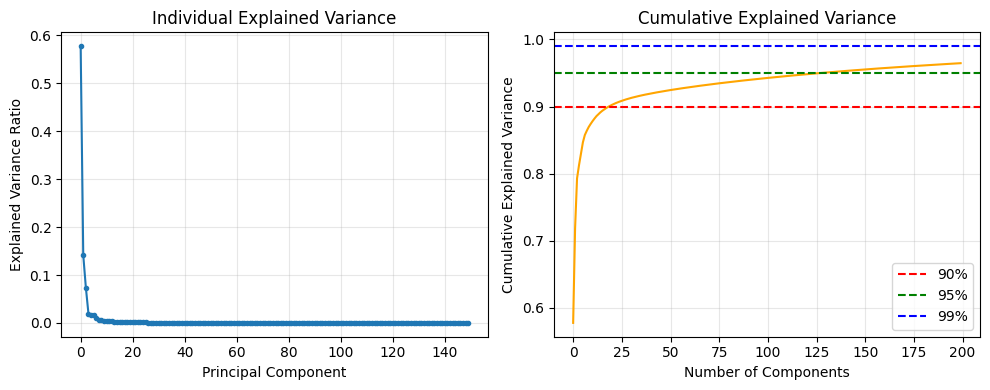

In [84]:
#Cumulative Explained Variance Plot
# Explained variance ratio for each component
total_variance      = np.sum(eigenvalues)
explained_variance  = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance)

# Find how many components explain 90%, 95%, 99%
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{int(threshold*100)}% variance explained by {k} components")

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(explained_variance[:150], marker='o', markersize=3)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Explained Variance")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:200], color='orange')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.99, color='b', linestyle='--', label='99%')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
#Step 3 - reconstruction function
def pca_reconstruct(centered_data, eigenvectors, mean, k):
    """
    Compress and reconstruct image using top-k principal components.

    Steps:
      1. Project data onto k eigenvectors  → lower-dim representation
      2. Project back to original space    → reconstruction
      3. Add mean back                     → undo centering
    """
    # Select top-k eigenvectors: shape (W, k)
    top_k_eigenvectors = eigenvectors[:, :k]

    # Step 1: Project — encode into k dimensions
    # centered_data: (H, W)  @  eigenvectors: (W, k)  →  scores: (H, k)
    scores = centered_data @ top_k_eigenvectors

    # Step 2: Reconstruct — decode back to W dimensions
    # scores: (H, k)  @  eigenvectors.T: (k, W)  →  reconstructed: (H, W)
    reconstructed = scores @ top_k_eigenvectors.T

    # Step 3: Add mean back
    reconstructed = reconstructed + mean

    # Clip to valid pixel range [0, 255]
    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed.astype(np.uint8)

In [86]:
#Step 4 - Experiment with different k vlaues
# Four different k values to compare
k_values = [10, 20, 50, 100, 150]

# Pre-compute all reconstructions
reconstructions = {}
for k in k_values:
    reconstructions[k] = pca_reconstruct(centered, eigenvectors, mean, k)
    var_explained = cumulative_variance[k-1] * 100
    print(f"k={k:4d} | Variance explained: {var_explained:.2f}%")

k=  10 | Variance explained: 87.41%
k=  20 | Variance explained: 90.12%
k=  50 | Variance explained: 92.41%
k= 100 | Variance explained: 94.24%
k= 150 | Variance explained: 95.51%


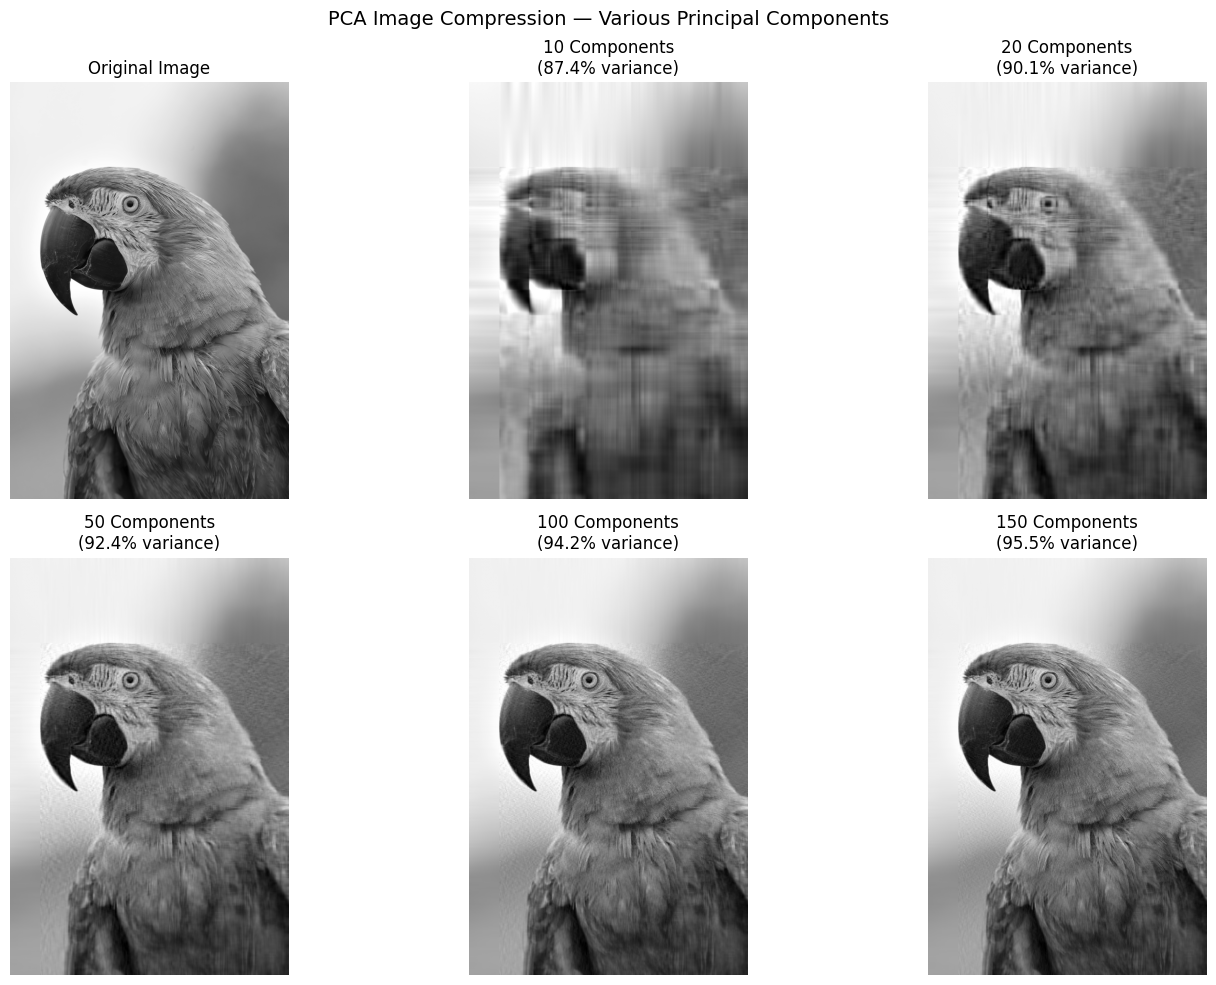

In [87]:
#Step5 - display all results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0][0].imshow(img_array.astype(np.uint8), cmap='gray')
axes[0][0].set_title("Original Image")
axes[0][0].axis("off")

# Reconstructed images
positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]
for (r, c), k in zip(positions, k_values):
    var = cumulative_variance[k-1] * 100
    axes[r][c].imshow(reconstructions[k], cmap='gray')
    axes[r][c].set_title(f"{k} Components\n({var:.1f}% variance)")
    axes[r][c].axis("off")

plt.suptitle("PCA Image Compression — Various Principal Components", fontsize=14)
plt.tight_layout()
plt.savefig("pca_compression.png", dpi=150)
plt.show()

In [88]:
#Step 6 - Evaluate with MSE and PSNR
def mse(original, reconstructed):
    return np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)

def psnr(original, reconstructed):
    error = mse(original, reconstructed)
    if error == 0:
        return float('inf')
    return 10 * np.log10(255**2 / error)

# Compression ratio = original size / compressed size
H, W = img_array.shape
original_size = H * W

print(f"\n{'k':>6} | {'Variance':>10} | {'MSE':>10} | {'PSNR (dB)':>10} | {'Compression':>12}")
print("-" * 60)
for k in k_values:
    var    = cumulative_variance[k-1] * 100
    err    = mse(img_array, reconstructions[k])
    p      = psnr(img_array, reconstructions[k])
    # Compressed size = k*(H + W + 1) numbers stored instead of H*W
    comp   = original_size / (k * (H + W + 1))
    print(f"{k:>6} | {var:>9.2f}% | {err:>10.2f} | {p:>10.2f} | {comp:>10.2f}x")



     k |   Variance |        MSE |  PSNR (dB) |  Compression
------------------------------------------------------------
    10 |     87.41% |     467.91 |      21.43 |     240.81x
    20 |     90.12% |     367.80 |      22.47 |     120.40x
    50 |     92.41% |     282.65 |      23.62 |      48.16x
   100 |     94.24% |     214.57 |      24.82 |      24.08x
   150 |     95.51% |     167.30 |      25.90 |      16.05x
